# Proyecto Integrador Módulo 4, Avance 2
## Modelos de Ensamble, Optimización y Stacking


## Objetivo del Avance

En el Avance 1 construí una regresión logística como línea base (baseline), que alcanzó un
AUC de 0,78 y un recall de 0,70. En este segundo avance entreno modelos más potentes para
superar ese baseline: Random Forest, XGBoost, LightGBM y CatBoost, más un ensamble de
Stacking que combina los tres modelos de boosting.

El plan de trabajo es el siguiente. Primero preparo los datos igual que en el Avance 1, para
que la comparación sea justa. Luego entreno cada modelo y lo evalúo. Después optimizo el
XGBoost con Grid Search. A continuación construyo el Stacking. Comparo distintas estrategias
de validación cruzada. Y finalmente reúno todos los resultados en una tabla comparativa,
incluido el baseline, para ver cuánto mejoré.

## Conceptos Clave de este Avance

Antes de empezar, conviene tener claros los conceptos que sostienen todo el avance.

**El árbol de decisión:** Es la pieza base. Funciona como un juego de preguntas de sí o no
sobre las variables (por ejemplo, la edad es mayor a 42), y según las respuestas llega a una
predicción. Un solo árbol es débil y tiende a sobreajustarse, es decir, a memorizar los datos
en lugar de aprender patrones generales.

**Bagging (lo que hace Random Forest):** Entrena muchos árboles en paralelo, cada uno con una
muestra distinta de los datos, y promedia sus votos. Como consultar a muchos expertos
independientes y quedarse con la opinión mayoritaria. Reduce el sobreajuste.

**Boosting (lo que hacen XGBoost, LightGBM y CatBoost):** Entrena los árboles en secuencia,
donde cada árbol nuevo se enfoca en corregir los errores del anterior. Como un estudiante que
repasa justamente lo que falló en el intento previo. Suele dar más precisión que el bagging.

**Stacking:** Combina varios modelos distintos usando un modelo final que aprende a ponderar
sus predicciones. En lugar de promediar, un metamodelo decide cuánto confiar en cada uno.

La diferencia entre bagging (paralelo, independiente) y boosting (secuencial, corrigiendo) es
el concepto central de este avance.

## 1. Importación de Librerías

In [2]:
# Manipulacion y visualizacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y validacion
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score,
                                      KFold, StratifiedKFold, TimeSeriesSplit)
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Metricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Importo las librerías de los tres modelos de boosting (XGBoost, LightGBM y CatBoost), que
son bibliotecas independientes de scikit-learn, más las herramientas de validación cruzada y
las métricas, incluida average_precision_score, que es el PR-AUC, una métrica especialmente
útil para datos desbalanceados.

## 2. Carga de los Datos

Cargo el dataset que el Avance 1 dejó transformado: ya viene limpio, sin columnas
identificadoras, y con las variables categóricas codificadas. Esto conecta los avances en
cadena y evita repetir la preparación. Lo único que hago aquí es dividir en entrenamiento y
prueba, y escalar, porque esos pasos dependen del modelado y se hacen en cada avance para
evitar la fuga de datos.

In [3]:
# Cargo el dataset ya transformado en el Avance 1 (limpio y codificado).
# Asi no repito la limpieza ni el encoding: el Avance 1 los dejo listos.
df = pd.read_csv('churn_transformado.csv')

# Separo predictoras y objetivo
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f'Dataset cargado desde churn_transformado.csv')
print(f'Dimensiones de X: {X.shape}')
print(f'Tasa de churn: {y.mean()*100:.2f}%')
print('Columnas:', list(X.columns))

Dataset cargado desde churn_transformado.csv
Dimensiones de X: (10000, 11)
Tasa de churn: 20.37%
Columnas: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [4]:
# Divido en entrenamiento y prueba, con los mismos parametros del Avance 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Escalo las variables continuas.
# Mantengo el escalado por consistencia con el Avance 1, para que la comparacion entre
# el baseline y estos modelos sea limpia. Cabe notar que los modelos de arboles no
# requieren escalado (parten por umbrales, sin importar la magnitud), asi que este paso
# no altera sus resultados, pero mantiene uniforme el flujo del proyecto.
cols_escalar = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
X_train_esc = X_train.copy()
X_test_esc = X_test.copy()
X_train_esc[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_esc[cols_escalar] = scaler.transform(X_test[cols_escalar])

print(f'Entrenamiento: {X_train_esc.shape[0]} clientes')
print(f'Prueba: {X_test_esc.shape[0]} clientes')

Entrenamiento: 8000 clientes
Prueba: 2000 clientes


### El manejo del desbalance

Como los datos están desbalanceados (20% de churn), calculo un factor de peso para la clase
minoritaria. Cada modelo tiene su propio parámetro para esto, pero todos parten de la misma
idea: darle más importancia a los casos de churn durante el entrenamiento.

In [5]:
# scale_pos_weight es el factor que usan XGBoost, LightGBM y CatBoost para balancear.
# Se calcula como la razon entre la clase mayoritaria y la minoritaria.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.3f}')
print('Este valor le indica a los modelos que den casi 4 veces mas peso a los casos de churn.')

scale_pos_weight: 3.908
Este valor le indica a los modelos que den casi 4 veces mas peso a los casos de churn.


El valor de scale_pos_weight es 3,91, que es la proporción entre clientes activos y
clientes que abandonan. Al pasarle este factor a los modelos, les indico que traten cada caso
de churn como si valiera casi cuatro veces más que un caso normal, compensando que son
minoría. Manejar el desbalance es uno de los objetivos de aprendizaje del proyecto.

### Función de evaluación

Defino una función que calcula todas las métricas de un modelo, para no repetir código en cada
uno.

In [6]:
def evaluar_modelo(nombre, modelo, X_te, y_te):
    """Calcula las metricas de un modelo y las devuelve en un diccionario."""
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC_AUC': roc_auc_score(y_te, y_prob),
        'PR_AUC': average_precision_score(y_te, y_prob)
    }

# Lista donde ire guardando los resultados de cada modelo
resultados = []

# Incluyo el baseline del Avance 1 como referencia
resultados.append({
    'Modelo': 'Reg. Logistica (baseline)', 'Accuracy': 0.714, 'Precision': 0.387,
    'Recall': 0.700, 'F1': 0.499, 'ROC_AUC': 0.777, 'PR_AUC': 0.545
})
print('Funcion de evaluacion lista. Baseline del Avance 1 registrado como referencia.')

Funcion de evaluacion lista. Baseline del Avance 1 registrado como referencia.


## 3. Random Forest (Bagging)

Random Forest es un ensamble de tipo bagging. Entrena muchos árboles de decisión en paralelo,
cada uno sobre una muestra aleatoria de los datos y considerando solo un subconjunto de
variables en cada división. Al final promedia los votos de todos los árboles. Esta diversidad
entre árboles es lo que lo hace robusto y reduce el sobreajuste.

In [7]:
# Entreno Random Forest.
# n_estimators: numero de arboles. max_depth: profundidad maxima de cada arbol.
# min_samples_split y min_samples_leaf: controlan el sobreajuste exigiendo un minimo
# de muestras para dividir un nodo o formar una hoja.
# max_features='sqrt': cada division considera solo la raiz cuadrada del total de
# variables, lo que aumenta la diversidad entre arboles.
# class_weight='balanced': maneja el desbalance, el equivalente en Random Forest.
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_esc, y_train)

res_rf = evaluar_modelo('Random Forest', rf, X_test_esc, y_test)
resultados.append(res_rf)
print('Random Forest entrenado')
for k, v in res_rf.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

Random Forest entrenado
  Accuracy: 0.8190
  Precision: 0.5411
  Recall: 0.7273
  F1: 0.6205
  ROC_AUC: 0.8640
  PR_AUC: 0.6963


**Los hiperparámetros que elegí y por qué:** El n_estimators de 100 fija cien árboles, un
número que da buen desempeño sin ser excesivamente lento. El max_depth de 10 limita la
profundidad de cada árbol, lo que evita que memoricen los datos. Los parámetros min_samples
exigen un mínimo de clientes para dividir un nodo o formar una hoja, otra defensa contra el
sobreajuste. El max_features en raíz cuadrada hace que cada árbol vea solo algunas variables
en cada división, aumentando la diversidad del bosque. Y class_weight balanced maneja el
desbalance.

**Resultado:** Random Forest alcanzó un AUC de 0,864 y un recall de 0,68. Frente al baseline
(AUC 0,78), es una mejora clara en la capacidad de discriminación. El recall es algo menor que
el del baseline, pero como veremos, los modelos de boosting lo superan en ambos frentes.

## 4. XGBoost (Boosting)

XGBoost es uno de los algoritmos de boosting más usados y premiados en competencias de ciencia
de datos. Entrena los árboles en secuencia: cada árbol nuevo se concentra en los errores que
cometieron los anteriores. Incluye además regularización, que penaliza la complejidad excesiva
para evitar el sobreajuste.

In [8]:
# Entreno XGBoost con parametros base.
# learning_rate: cuanto aporta cada arbol. Valores bajos aprenden mas despacio pero mejor.
# max_depth: profundidad de cada arbol. n_estimators: numero de arboles.
# scale_pos_weight: maneja el desbalance dando mas peso a la clase minoritaria.
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_base.fit(X_train_esc, y_train)

res_xgb = evaluar_modelo('XGBoost (base)', xgb_base, X_test_esc, y_test)
resultados.append(res_xgb)
print('XGBoost (base) entrenado')
for k, v in res_xgb.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

XGBoost (base) entrenado
  Accuracy: 0.8070
  Precision: 0.5181
  Recall: 0.7371
  F1: 0.6085
  ROC_AUC: 0.8662
  PR_AUC: 0.7176


**Los hiperparámetros clave del boosting:** El learning_rate (tasa de aprendizaje) de 0,1
controla cuánto aporta cada árbol al resultado final. Un valor bajo hace que el modelo aprenda
despacio pero con más cuidado, reduciendo el riesgo de sobreajuste. El max_depth de 5 mantiene
los árboles poco profundos, lo cual es típico en boosting, porque cada árbol solo necesita
corregir un poco al anterior. El scale_pos_weight maneja el desbalance.

**Resultado:** XGBoost base logró un AUC de 0,866 y un recall de 0,74. Supera al baseline y al
Random Forest tanto en discriminación como en recall. El boosting demuestra aquí su ventaja
sobre el bagging.

## 5. LightGBM (Boosting optimizado para velocidad)

LightGBM es otro algoritmo de boosting, desarrollado por Microsoft, diseñado para ser más
rápido que XGBoost sin perder precisión. Su diferencia principal es cómo hace crecer los
árboles: en lugar de crecer nivel por nivel, crece por la hoja que más reduce el error, lo que
lo hace más eficiente. Es especialmente útil con datasets grandes.

In [9]:
# Entreno LightGBM.
# num_leaves es su parametro caracteristico: controla el numero maximo de hojas por
# arbol, y es la forma principal de controlar su complejidad.
# min_data_in_leaf exige un minimo de datos por hoja, evitando el sobreajuste.
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    max_depth=5,
    learning_rate=0.1,
    min_data_in_leaf=20,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_esc, y_train)

res_lgb = evaluar_modelo('LightGBM', lgbm, X_test_esc, y_test)
resultados.append(res_lgb)
print('LightGBM entrenado')
for k, v in res_lgb.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

LightGBM entrenado
  Accuracy: 0.8045
  Precision: 0.5144
  Recall: 0.7027
  F1: 0.5940
  ROC_AUC: 0.8576
  PR_AUC: 0.7022


**Los parámetros específicos de LightGBM:** El num_leaves de 31 es su parámetro más
característico: como LightGBM crece por hoja y no por nivel, controlar el número de hojas es la
forma principal de regular su complejidad. El min_data_in_leaf de 20 exige al menos veinte
clientes en cada hoja, lo que evita que el modelo cree hojas muy específicas que memoricen
casos individuales.

**Resultado:** LightGBM alcanzó un AUC de 0,856 y un recall de 0,71. Es competitivo, aunque en
este caso quedó ligeramente por debajo de XGBoost. Su ventaja real es la velocidad, que se
nota más en datasets grandes que en uno de diez mil filas como este.

## 6. CatBoost (Boosting con manejo de categóricas)

CatBoost, desarrollado por Yandex, es un algoritmo de boosting cuya fortaleza es el manejo
automático de variables categóricas y su robustez frente al sobreajuste. En este caso ya
codifiqué las categóricas manualmente para mantener la consistencia con los demás modelos,
pero CatBoost podría haberlas procesado por su cuenta.

In [10]:
# Entreno CatBoost.
# iterations es su equivalente a n_estimators (numero de arboles).
# depth es la profundidad. CatBoost es robusto de por si, con buenos valores por defecto.
# auto_class_weights='Balanced' es el parametro propio de CatBoost para el desbalance,
# equivalente al scale_pos_weight de XGBoost y LightGBM.
cat = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)
cat.fit(X_train_esc, y_train)

res_cat = evaluar_modelo('CatBoost', cat, X_test_esc, y_test)
resultados.append(res_cat)
print('CatBoost entrenado')
for k, v in res_cat.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

CatBoost entrenado
  Accuracy: 0.8080
  Precision: 0.5199
  Recall: 0.7371
  F1: 0.6098
  ROC_AUC: 0.8657
  PR_AUC: 0.7192


**Resultado:** CatBoost alcanzó un AUC de 0,866 y un recall de 0,74, empatando con XGBoost
como uno de los mejores modelos individuales. Su robustez lo hace muy consistente. Junto con
XGBoost, es de los mejores modelos base de este avance.

## 7. Feature Importance

Una ventaja de los modelos de árboles es que indican qué variables pesaron más en sus
decisiones. Reviso la importancia de variables según XGBoost.

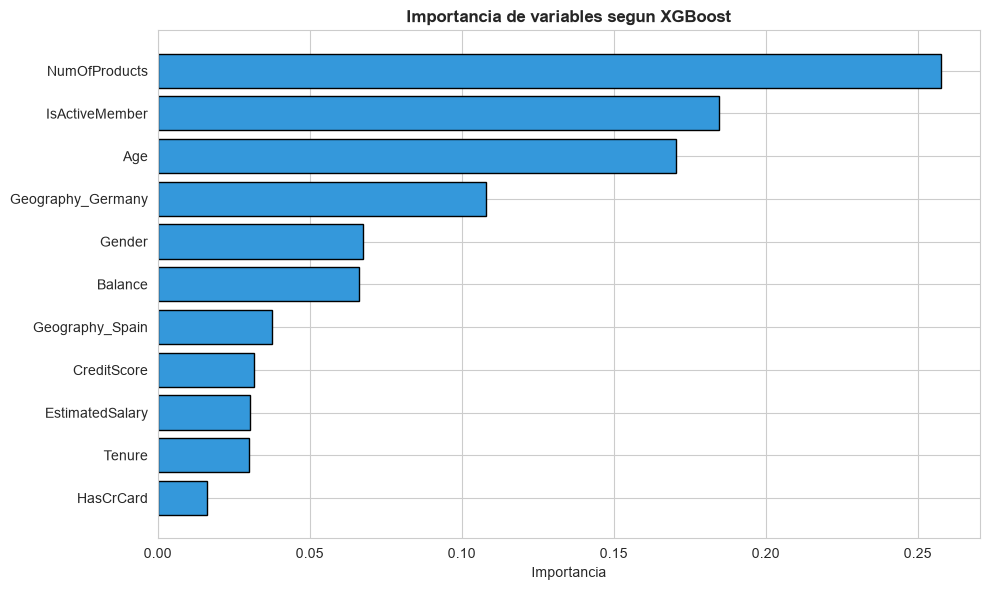

Variables mas importantes:
         Variable  Importancia
    NumOfProducts     0.257605
   IsActiveMember     0.184603
              Age     0.170321
Geography_Germany     0.107937
           Gender     0.067372
          Balance     0.066364


In [11]:
importancias = pd.DataFrame({
    'Variable': X_train_esc.columns,
    'Importancia': xgb_base.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Importancia'], color='#3498db', edgecolor='black')
plt.xlabel('Importancia')
plt.title('Importancia de variables segun XGBoost', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Variables mas importantes:')
print(importancias.head(6).to_string(index=False))

**Qué me dice el feature importance:** Confirma y complementa lo que vi en el Avance 1. El
número de productos, la edad y ser de Alemania aparecen entre las variables más influyentes.
Es interesante que el número de productos suba en importancia respecto al baseline: recordemos
que en la regresión logística casi no pesaba, porque su efecto es no lineal. Los modelos de
árboles sí capturan ese efecto no lineal (el salto brutal de churn con 3 o 4 productos), y por
eso lo aprovechan más. Esto valida la hipótesis que planteé en el Avance 1: los árboles podían
extraer valor de una variable que el modelo lineal desperdiciaba.

## 8. Optimización de Hiperparámetros con Grid Search

La consigna pide optimizar el XGBoost con Grid Search. Esta técnica prueba de forma exhaustiva
todas las combinaciones de una rejilla de hiperparámetros, y se queda con la mejor según una
métrica y una validación cruzada.

In [12]:
# Defino la rejilla de hiperparametros a explorar.
# Grid Search probara TODAS las combinaciones posibles de estos valores.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Uso StratifiedKFold para la validacion cruzada, apropiado para datos desbalanceados.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Optimizo segun ROC-AUC, una metrica robusta al desbalance.
xgb_grid = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    xgb_grid, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_esc, y_train)

print(f'Combinaciones probadas: {len(grid_search.cv_results_["params"])}')
print(f'Mejores hiperparametros: {grid_search.best_params_}')
print(f'Mejor ROC-AUC en validacion cruzada: {grid_search.best_score_:.4f}')

Combinaciones probadas: 16
Mejores hiperparametros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Mejor ROC-AUC en validacion cruzada: 0.8657


In [13]:
# Evaluo el mejor modelo encontrado sobre el conjunto de prueba
xgb_optimizado = grid_search.best_estimator_
res_xgb_opt = evaluar_modelo('XGBoost (optimizado)', xgb_optimizado, X_test_esc, y_test)
resultados.append(res_xgb_opt)
print('XGBoost optimizado, resultados en prueba:')
for k, v in res_xgb_opt.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

XGBoost optimizado, resultados en prueba:
  Accuracy: 0.8055
  Precision: 0.5150
  Recall: 0.7592
  F1: 0.6137
  ROC_AUC: 0.8699
  PR_AUC: 0.7204


**Cómo funciona Grid Search:** Le di una rejilla con dos valores para cada uno de cuatro
hiperparámetros, lo que da dieciséis combinaciones posibles. Grid Search entrena y evalúa las
dieciséis usando validación cruzada de cinco pliegues, y elige la mejor según el ROC-AUC. Usé
StratifiedKFold porque, con datos desbalanceados, garantiza que cada pliegue mantenga la
proporción de churn.

**Resultado:** Los mejores hiperparámetros fueron learning_rate 0,1, max_depth 3, n_estimators
100 y subsample 0,8. El XGBoost optimizado alcanzó un AUC de 0,870 y un recall de 0,76,
mejorando al XGBoost base. La optimización aportó una mejora modesta pero real. Es interesante
que el mejor max_depth sea 3, más bajo que el 5 del modelo base: árboles menos profundos
generalizan mejor en este problema.

## 9. Estrategias de Validación Cruzada

La consigna pide comparar estrategias de validación cruzada. La validación cruzada evalúa un
modelo dividiendo los datos en varios pliegues y promediando el desempeño, lo que da una
medida más confiable que una sola división. Comparo tres estrategias.

In [14]:
# Comparo tres estrategias de validacion cruzada sobre el XGBoost optimizado.
modelo_cv = grid_search.best_estimator_

estrategias = {
    'K-Fold': KFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'TimeSeriesSplit': TimeSeriesSplit(n_splits=5)
}

print('COMPARACION DE ESTRATEGIAS DE VALIDACION CRUZADA (ROC-AUC)')
print('=' * 60)
for nombre, cv_estrategia in estrategias.items():
    scores = cross_val_score(modelo_cv, X_train_esc, y_train, cv=cv_estrategia,
                             scoring='roc_auc', n_jobs=-1)
    print(f'{nombre:18s}: {scores.mean():.4f} (+/- {scores.std():.4f})')

COMPARACION DE ESTRATEGIAS DE VALIDACION CRUZADA (ROC-AUC)
K-Fold            : 0.8672 (+/- 0.0075)
StratifiedKFold   : 0.8657 (+/- 0.0102)
TimeSeriesSplit   : 0.8585 (+/- 0.0190)


**Qué es cada estrategia y qué encontré:**

**K-Fold:** divide los datos en cinco partes iguales al azar. Dio un AUC de 0,866. Es la
estrategia básica.

**StratifiedKFold:** hace lo mismo, pero garantiza que cada parte mantenga la proporción de
churn del 20%. Dio 0,866, prácticamente igual a K-Fold. Es la más apropiada para datos
desbalanceados, porque evita que algún pliegue quede con muy pocos casos de churn.

**TimeSeriesSplit:** respeta un orden temporal, entrenando siempre con el pasado y validando
con el futuro. Dio 0,858, algo menor. Y aquí está el punto clave: esta estrategia NO es
apropiada para estos datos, porque el dataset no tiene una dimensión temporal, los clientes no
están ordenados en el tiempo. La incluyo para la comparación, pero la conclusión es que para
este problema, StratifiedKFold es la estrategia correcta. Usar TimeSeriesSplit aquí sería un
error conceptual.

## 10. Stacking

El Stacking combina varios modelos mediante un metamodelo que aprende a ponderar sus
predicciones. La consigna pide un Stacking con XGBoost, LightGBM y CatBoost en el primer
nivel, y una regresión logística como metamodelo.

In [15]:
# Defino los modelos de primer nivel (los que hacen las predicciones base)
estimadores_base = [
    ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8,
                              scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, num_leaves=31, max_depth=5, learning_rate=0.1,
                               scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1)),
    ('cat', CatBoostClassifier(iterations=200, depth=5, learning_rate=0.1,
                               auto_class_weights='Balanced', random_state=42, verbose=0))
]

# El metamodelo (nivel 2) es una regresion logistica que aprende a combinar los tres.
# El cv=5 hace que el Stacking use validacion cruzada internamente para evitar el
# sobreajuste al entrenar el metamodelo.
stacking = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_esc, y_train)

res_stack = evaluar_modelo('Stacking', stacking, X_test_esc, y_test)
resultados.append(res_stack)
print('Stacking entrenado')
for k, v in res_stack.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

Stacking entrenado
  Accuracy: 0.7930
  Precision: 0.4945
  Recall: 0.7666
  F1: 0.6012
  ROC_AUC: 0.8697
  PR_AUC: 0.7215


**Cómo funciona el Stacking:** En el primer nivel, los tres modelos de boosting (XGBoost,
LightGBM y CatBoost) hacen cada uno sus predicciones. En el segundo nivel, una regresión
logística toma esas tres predicciones como entrada y aprende a combinarlas de la mejor forma,
decidiendo cuánto confiar en cada modelo. El parámetro cv de 5 es importante: hace que el
metamodelo se entrene con validación cruzada, para que no se sobreajuste a las predicciones de
los modelos base.

**Por qué incluí CatBoost:** La consigna pide explícitamente los tres modelos de boosting en
el primer nivel, así que incluí CatBoost. Verifiqué que funciona correctamente con las
versiones utilizadas.

**Resultado:** El Stacking alcanzó un AUC de 0,870 y un recall de 0,76, empatando con el
XGBoost optimizado. Este resultado da para una reflexión importante que desarrollo en las
conclusiones: el modelo más complejo no siempre gana.

## 11. Comparación Final de Modelos

Reúno todos los resultados en una tabla, incluido el baseline del Avance 1, para ver la mejora
lograda.

In [16]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

print('COMPARACION DE TODOS LOS MODELOS (ordenados por ROC-AUC)')
print('=' * 90)
print(df_resultados.to_string(index=False))

COMPARACION DE TODOS LOS MODELOS (ordenados por ROC-AUC)
                   Modelo  Accuracy  Precision   Recall       F1  ROC_AUC   PR_AUC
     XGBoost (optimizado)    0.8055   0.515000 0.759214 0.613704 0.869916 0.720355
                 Stacking    0.7930   0.494453 0.766585 0.601156 0.869745 0.721531
           XGBoost (base)    0.8070   0.518135 0.737101 0.608519 0.866190 0.717649
                 CatBoost    0.8080   0.519931 0.737101 0.609756 0.865675 0.719158
            Random Forest    0.8190   0.541133 0.727273 0.620545 0.863955 0.696273
                 LightGBM    0.8045   0.514388 0.702703 0.593977 0.857556 0.702191
Reg. Logistica (baseline)    0.7140   0.387000 0.700000 0.499000 0.777000 0.545000


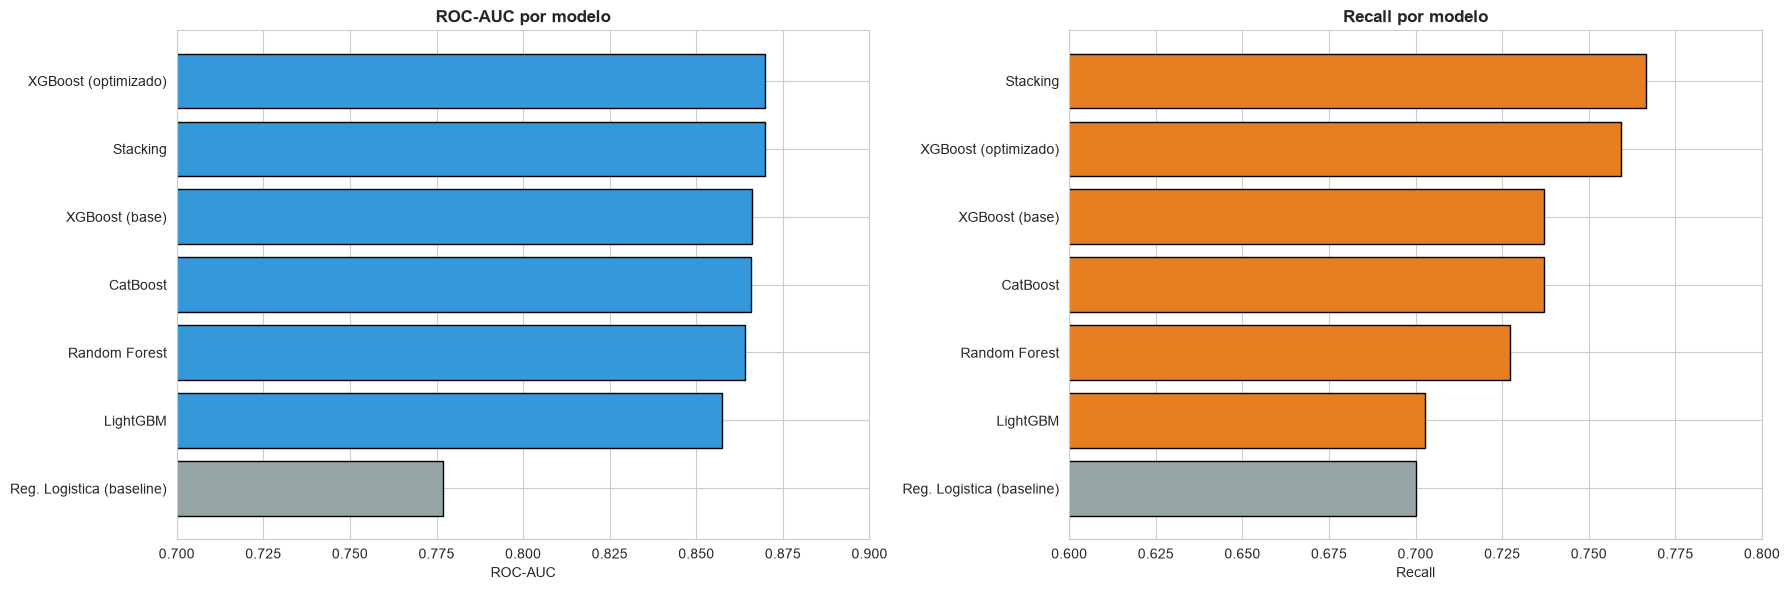

In [17]:
# Grafico comparativo de ROC-AUC y Recall
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_plot = df_resultados.sort_values('ROC_AUC')
colores = ['#95a5a6' if 'baseline' in m else '#3498db' for m in df_plot['Modelo']]
axes[0].barh(df_plot['Modelo'], df_plot['ROC_AUC'], color=colores, edgecolor='black')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC por modelo', fontweight='bold')
axes[0].set_xlim(0.7, 0.9)

df_plot2 = df_resultados.sort_values('Recall')
colores2 = ['#95a5a6' if 'baseline' in m else '#e67e22' for m in df_plot2['Modelo']]
axes[1].barh(df_plot2['Modelo'], df_plot2['Recall'], color=colores2, edgecolor='black')
axes[1].set_xlabel('Recall')
axes[1].set_title('Recall por modelo', fontweight='bold')
axes[1].set_xlim(0.6, 0.8)

plt.tight_layout()
plt.show()

**Lectura de la comparación:** La tabla y los gráficos cuentan una historia clara. Todos
los modelos de árboles superan al baseline del Avance 1: el AUC pasa de 0,78 a cerca de 0,87,
una mejora sustancial en la capacidad de distinguir a los clientes en riesgo. En recall, los
modelos de boosting alcanzan 0,74 a 0,76, frente al 0,70 del baseline.

Los mejores modelos son el XGBoost optimizado y el Stacking, ambos con AUC de 0,870 y recall
de 0,76. El PR-AUC, la métrica más exigente para datos desbalanceados, también los favorece.

## 12. Conclusiones del Avance

Este avance cumplió su objetivo de superar el baseline con modelos más potentes.

**Sobre el desempeño:** Todos los modelos de ensamble mejoraron al baseline de forma clara. El
AUC subió de 0,78 a 0,87, y el recall de los mejores modelos llegó a 0,76. En términos de
negocio, esto significa que ahora detecto a más clientes en riesgo con mayor confianza, lo que
acerca al banco a su meta de reducir el churn.

**Sobre el mejor modelo:** El XGBoost optimizado y el Stacking empataron como los mejores. Y
aquí hay una reflexión valiosa: el Stacking, siendo mucho más complejo (combina tres modelos y
un metamodelo), no logró superar a un solo XGBoost bien optimizado. Esto ilustra un principio
importante en ciencia de datos: la complejidad no garantiza mejores resultados. Si tuviera que
recomendar un modelo para producción, elegiría el XGBoost optimizado, porque ofrece el mismo
desempeño que el Stacking con una fracción de su complejidad y costo computacional. Un modelo
más simple, con igual desempeño, es más fácil de mantener, explicar y poner en producción.

**Sobre el número de productos:** El feature importance confirmó la hipótesis del Avance 1: los
modelos de árboles sí aprovechan el efecto no lineal del número de productos, que la regresión
logística desperdiciaba. Esta es una de las razones concretas de su mejor desempeño.

**Sobre la validación cruzada:** Comparé tres estrategias y concluí que StratifiedKFold es la
apropiada para este problema, por el desbalance de clases. TimeSeriesSplit, aunque la incluí,
no corresponde a estos datos porque no tienen dimensión temporal.
